In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = Path("../data/raw")

train_transaction_path = DATA_DIR / "train_transaction.csv"
train_identity_path = DATA_DIR / "train_identity.csv"

print(train_transaction_path)
print(train_identity_path)

..\data\raw\train_transaction.csv
..\data\raw\train_identity.csv


In [4]:
for file in DATA_DIR.iterdir():
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"{file.name:30} {size_mb:,.1f} MB")

sample_submission.csv          5.8 MB
test_identity.csv              24.6 MB
test_transaction.csv           584.8 MB
train_identity.csv             25.3 MB
train_transaction.csv          651.7 MB


In [5]:
train_sample = pd.read_csv(
    train_transaction_path,
    nrows = 10_000
)

train_sample.shape

(10000, 394)

In [6]:
train_sample.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
train_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 30.1 MB


In [8]:
train_sample["isFraud"].value_counts()

isFraud
0    9735
1     265
Name: count, dtype: int64

In [9]:
train_sample["isFraud"].value_counts(normalize= True)

isFraud
0    0.9735
1    0.0265
Name: proportion, dtype: float64

In [10]:
# Fraud rate
fraud_rate = train_sample["isFraud"].mean()

print(f"Fraud rate: {fraud_rate:.2%}")

Fraud rate: 2.65%


In [11]:
# Transaction time range
print("TransactionDT minimum:", train_sample["TransactionDT"].min())
print("TransactionDT maximum:", train_sample["TransactionDT"].max())

TransactionDT minimum: 86400
TransactionDT maximum: 313121


In [12]:
# Check whether TransactionDT is ordered
is_sorted = train_sample["TransactionDT"].is_monotonic_increasing

print("TransactionDT sorted:", is_sorted)

TransactionDT sorted: True


In [13]:
pd.set_option("display.max_rows", 400)

print(train_sample.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [14]:
# Missing values by column

missing = train_sample.isna().sum().sort_values(ascending = False)

missing_percentage = (
    train_sample.isna().mean() * 100
).sort_values(ascending = False)

missing_sumamry = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_sumamry.head(30)

,missing_count,missing_percentage
D7,9777,97.77
D13,9720,97.20
dist2,9622,96.22
D12,9594,95.94
D14,9550,95.50
D6,9509,95.09
D8,8900,89.00
D9,8900,89.00
V152,8618,86.18
V142,8618,86.18


In [15]:
(train_sample.isna().all()).sum()

np.int64(0)

In [16]:
(missing_percentage > 50).sum()

np.int64(208)

In [17]:
(missing_percentage > 90).sum()

np.int64(6)

In [18]:
train_sample.groupby("isFraud")["D7"].apply(lambda x: x.isna().mean() * 100)

isFraud
0    97.925013
1    92.075472
Name: D7, dtype: float64

In [19]:
train_sample["D7_missing"] = train_sample["D7"].isna().astype(int)

C:\Users\niles\AppData\Local\Temp\ipykernel_15576\3803323638.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["D7_missing"] = train_sample["D7"].isna().astype(int)


In [20]:
train_sample = train_sample.drop(columns=["D7_missing"])

In [21]:
high_missing_cols = missing_percentage[missing_percentage > 90].index

high_missing_cols

Index(['D7', 'D13', 'dist2', 'D12', 'D14', 'D6'], dtype='str')

In [22]:
for col in high_missing_cols:
    fraud_missing_rate= (
        train_sample.groupby("isFraud")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{col}")
    print(fraud_missing_rate)


D7
isFraud
0    97.925013
1    92.075472
Name: D7, dtype: float64

D13
isFraud
0    97.298408
1    93.584906
Name: D13, dtype: float64

dist2
isFraud
0    96.281459
1    93.962264
Name: dist2, dtype: float64

D12
isFraud
0    96.147920
1    88.301887
Name: D12, dtype: float64

D14
isFraud
0    95.839753
1    83.018868
Name: D14, dtype: float64

D6
isFraud
0    95.285054
1    87.924528
Name: D6, dtype: float64


In [ ]:
# Find the columns where more than 90% of values are missing
high_missing_cols = missing_percentage[missing_percentage > 90].index

# Empty list to store our results
missingness_by_fraud = []

# Check each highly-missing column
for col in high_missing_cols:
    # Calculate the percantage of missing values separately for legitmate(0) and fraud(1) transactions
    missing_by_target = (
        train_sample.groupby("isFraud")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    missingness_by_fraud.append({
    "feature": col,
    "legitmate_missing_%": missing_by_target.get(0,0),
    "fraud_missing_%": missing_by_target.get(1,0)

    })

#Convert our list of dictionaries into a DataFrame
missingness_comparision = pd.DataFrame(missingness_by_fraud)

# Difference in missingness between legitmate and fraudulent transactions
missingness_comparision["difference_pp"] = (
    missingness_comparision["legitmate_missing_%"] - missingness_comparision["fraud_missing_%"]
)

missingness_comparision.sort_values(
    "difference_pp", ascending= False
)



,feature,legitmate_missing_%,fraud_missing_%,difference_pp
4,D14,95.839753,83.018868,12.820886
3,D12,96.147920,88.301887,7.846033
5,D6,95.285054,87.924528,7.360526
0,D7,97.925013,92.075472,5.849541
1,D13,97.298408,93.584906,3.713502
2,dist2,96.281459,93.962264,2.319195


### Missingness and Fraud

Several highly-missing features show different missingness patterns between
legitimate and fraudulent transactions.

Among features with more than 90% missing values, D14 shows the largest
difference: approximately 95.84% of legitimate transactions have D14 missing,
compared with 83.02% of fraudulent transactions.

This suggests that missingness itself may contain predictive information.
Therefore, highly-missing features should not automatically be removed solely
because of their missing-value percentage. During feature engineering, we will
evaluate whether missingness indicators improve fraud detection performance.

These observations are based on an initial 10,000-row sample and will need to
be validated on the full training dataset.

In [24]:
# Count how many transactions belong to each ProductCD category
product_counts = train_sample["ProductCD"].value_counts()

# Display the number of transactions in each category
product_counts

ProductCD
W    7709
C     906
H     871
R     305
S     209
Name: count, dtype: int64

In [25]:
# Calculate the number of transactions in each ProductCD category
product_summary = train_sample.groupby("ProductCD").agg(
    transactions = ("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

# Calculate the percentage of fraudelent transactions within each ProductCD category
product_summary["fraud_rate_%"] = (
    product_summary["fraud_count"]/product_summary["transactions"] * 100
)

#Sort categories by highest to lowest fraud rate
product_summary.sort_values(
    "fraud_rate_%", ascending= False
)

,transactions,fraud_count,fraud_rate_%
ProductCD,,,
C,906,94,10.375276
R,305,17,5.573770
S,209,10,4.784689
W,7709,132,1.712284
H,871,12,1.377727


In [26]:
# Calculate what percentage of all fraud cases comes from each ProductCD category
product_summary["share_of_all_fraud_%"] = (
    product_summary["fraud_count"]/product_summary["fraud_count"].sum() * 100
)

# Updated summary
product_summary.sort_values(
    "fraud_count", ascending= False
)

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
ProductCD,,,,
W,7709,132,1.712284,49.811321
C,906,94,10.375276,35.471698
R,305,17,5.573770,6.415094
H,871,12,1.377727,4.528302
S,209,10,4.784689,3.773585


In [27]:
# Count number of transactions belonging to each card4 category to understand the distribution before calculating fraud rates.
card4_counts = train_sample["card4"].value_counts(dropna=False)

# Display the counts
card4_counts

card4
visa                6209
mastercard          3586
american express     112
discover              92
NaN                    1
Name: count, dtype: int64

In [ ]:
# Group transactions by card4 category and count total transactions and fraudulent transactions.
card4_summary = train_sample.groupby("card4", dropna=False).agg( 
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
) # Use dropna False to appear missing value as its own category

# Percentage of transactions that are fraudulent within each card4 category.
card4_summary["fraud_rate_%"] = (
    card4_summary["fraud_count"]
    / card4_summary["transactions"]
    * 100
)

card4_summary.sort_values(
    "fraud_rate_%",
    ascending=False
)


,transactions,fraud_count,fraud_rate_%
card4,,,
mastercard,3586,117,3.262688
discover,92,3,3.260870
visa,6209,143,2.303108
american express,112,2,1.785714
NaN,1,0,0.000000


In [29]:
# Count transactions for each card6 category.
card6_counts = train_sample["card6"].value_counts(
    dropna=False
)

card6_counts

card6
debit     7891
credit    2108
NaN          1
Name: count, dtype: int64

In [ ]:
# Group transactions by card6 category.
card6_summary = train_sample.groupby("card6", dropna=False).agg(
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

card6_summary["fraud_rate_%"] = (
    card6_summary["fraud_count"]
    / card6_summary["transactions"]
    * 100
)

card6_summary.sort_values(
    "fraud_rate_%",
    ascending=False
)

,transactions,fraud_count,fraud_rate_%
card6,,,
credit,2108,150,7.115750
debit,7891,115,1.457356
NaN,1,0,0.000000


In [ ]:
# Create reusable function to inspect different columns
def analyze_categorical_feature(data, column, min_transactions=10):
    summary = data.groupby(column, dropna=False).agg(
        transactions=("isFraud", "count"),
        fraud_count=("isFraud", "sum")
    )

    summary["fraud_rate_%"] = (
        summary["fraud_count"]
        / summary["transactions"]
        * 100
    )

    summary["share_of_all_fraud_%"] = (
        summary["fraud_count"]
        / summary["fraud_count"].sum()
        * 100
    )

    # Keep only categories with enough observations.
    summary = summary[
        summary["transactions"] >= min_transactions
    ]

    summary = summary.sort_values(
        "fraud_rate_%",
        ascending=False
    )

    return summary

In [ ]:
card6_analysis = analyze_categorical_feature(
    train_sample,
    "card6"
)

# Display the result.
card6_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
card6,,,,
credit,2108,150,7.115750,56.603774
debit,7891,115,1.457356,43.396226


In [ ]:
# Count the email-domain categories.
email_counts = train_sample["P_emaildomain"].value_counts(
    dropna=False
)

# Show the 20 most common categories.
email_counts.head(20)

P_emaildomain
gmail.com        3677
NaN              2105
yahoo.com        1726
hotmail.com       633
anonymous.com     490
aol.com           418
comcast.net       153
icloud.com         98
outlook.com        84
msn.com            59
att.net            53
charter.net        51
sbcglobal.net      50
verizon.net        49
ymail.com          44
live.com           43
me.com             31
bellsouth.net      31
yahoo.com.mx       23
cox.net            18
Name: count, dtype: int64

In [ ]:
# Analyze fraud rate for each purchaser email domain.

email_analysis = analyze_categorical_feature(
    train_sample,
    "P_emaildomain",
    min_transactions=20
)

email_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
P_emaildomain,,,,
outlook.com,84,12,14.285714,4.528302
ymail.com,44,4,9.090909,1.509434
hotmail.com,633,32,5.055292,12.075472
icloud.com,98,4,4.081633,1.509434
me.com,31,1,3.225806,0.377358
gmail.com,3677,118,3.209138,44.528302
NaN,2105,48,2.280285,18.113208
aol.com,418,9,2.153110,3.396226
anonymous.com,490,10,2.040816,3.773585


In [ ]:
# Analyze fraud rates for recipient email domains.

r_email_analysis = analyze_categorical_feature(
    train_sample,
    "R_emaildomain",
    min_transactions=20
)

r_email_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
R_emaildomain,,,,
outlook.com,64,12,18.750000,4.528302
gmail.com,642,77,11.993769,29.056604
hotmail.com,346,22,6.358382,8.301887
yahoo.com,124,6,4.838710,2.264151
anonymous.com,233,4,1.716738,1.509434
NaN,8375,140,1.671642,52.830189
comcast.net,31,0,0.000000,0.000000
aol.com,22,0,0.000000,0.000000
yahoo.com.mx,23,0,0.000000,0.000000


In [ ]:
train_sample["TransactionAmt"].describe()

count    10000.000000
mean       131.532165
std        215.136534
min          1.896000
25%         44.000000
50%         74.950000
75%        131.058000
max       3247.910000
Name: TransactionAmt, dtype: float64

In [ ]:
# Compare transaction amounts between legitimate and fraudulent transactions.

train_sample.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,9735.0,131.034187,215.149402,1.896,44.000,72.990,130.5,3247.91
1,265.0,149.825823,214.265761,5.000,48.336,83.742,159.0,2161.00


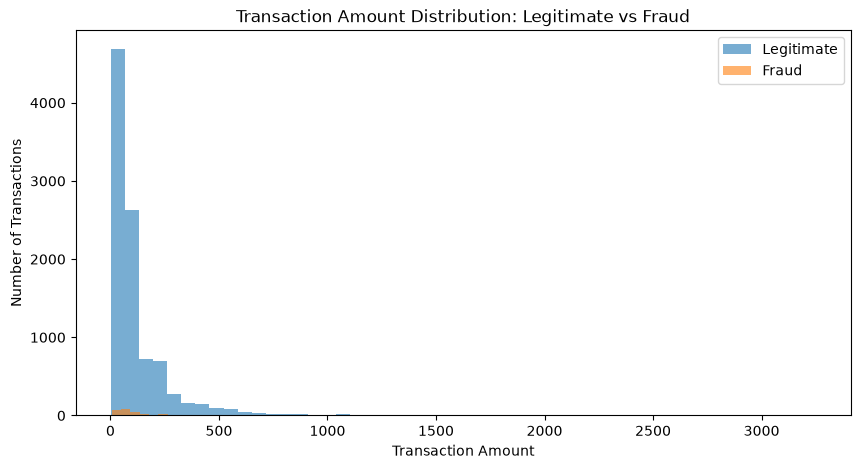

In [ ]:
# Separate transaction amounts into legitimate and fraudulent transactions.
legit_amounts = train_sample.loc[
    train_sample["isFraud"] == 0,
    "TransactionAmt"
]

fraud_amounts = train_sample.loc[
    train_sample["isFraud"] == 1,
    "TransactionAmt"
]

plt.figure(figsize=(10, 5))

plt.hist(
    legit_amounts,
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_amounts,
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Legitimate vs Fraud")
plt.legend()
plt.show()

In [ ]:
# Divide transaction amounts into ranges so we can compare the fraud rate across different transaction sizes.
amount_bins = [0, 25, 50, 100, 200, 500, 1000, 5000]

train_sample["amount_bin"] = pd.cut(
    train_sample["TransactionAmt"],
    bins=amount_bins,
    include_lowest=True
)

amount_analysis = train_sample.groupby(
    "amount_bin",
    observed=False
).agg(
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

amount_analysis["fraud_rate_%"] = (
    amount_analysis["fraud_count"]
    / amount_analysis["transactions"]
    * 100
)

amount_analysis

C:\Users\niles\AppData\Local\Temp\ipykernel_15576\2742472733.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["amount_bin"] = pd.cut(


,transactions,fraud_count,fraud_rate_%
amount_bin,,,
"(-0.001, 25.0]",962,30,3.118503
"(25.0, 50.0]",2672,49,1.833832
"(50.0, 100.0]",2814,85,3.020611
"(100.0, 200.0]",2011,52,2.585778
"(200.0, 500.0]",1198,34,2.838063
"(500.0, 1000.0]",246,13,5.284553
"(1000.0, 5000.0]",97,2,2.061856


In [ ]:
# Remove the temporary amount-bin column.
train_sample.drop(
    columns="amount_bin",
    inplace=True
)

In [41]:
train_sample["TransactionDT"].describe()

count     10000.000000
mean     186909.442000
std       56572.671722
min       86400.000000
25%      146628.750000
50%      171644.000000
75%      240112.000000
max      313121.000000
Name: TransactionDT, dtype: float64

In [ ]:
# Check whether TransactionDT is already sorted in our sample.
train_sample["TransactionDT"].is_monotonic_increasing

True

In [ ]:
# Convert TransactionDT from seconds into days.

train_sample["TransactionDay"] = (
    (train_sample["TransactionDT"] - train_sample["TransactionDT"].min())
    / 86400
)

train_sample["TransactionDay"] = (
    train_sample["TransactionDay"].astype(int)
)

# Calculate transaction volume and fraud rate for each day.
daily_fraud = train_sample.groupby("TransactionDay").agg(
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

daily_fraud["fraud_rate_%"] = (
    daily_fraud["fraud_count"]
    / daily_fraud["transactions"]
    * 100
)

daily_fraud

C:\Users\niles\AppData\Local\Temp\ipykernel_15576\484837437.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["TransactionDay"] = (


,transactions,fraud_count,fraud_rate_%
TransactionDay,,,
0,5122,112,2.186646
1,3730,123,3.297587
2,1148,30,2.613240


In [ ]:
# Remove the temporary TransactionDay feature.
train_sample.drop(
    columns="TransactionDay",
    inplace=True
)

In [45]:
feature_groups = {
    "C": [col for col in train_sample.columns if col.startswith("C")],
    "D": [col for col in train_sample.columns if col.startswith("D")],
    "M": [col for col in train_sample.columns if col.startswith("M")],
    "V": [col for col in train_sample.columns if col.startswith("V")]
}

for group, columns in feature_groups.items():
    print(f"{group}: {len(columns)} columns")

C: 14 columns
D: 15 columns
M: 9 columns
V: 339 columns


In [ ]:
# Calculate the average percentage of missing values across each major feature group.

group_missingness = {}

for group, columns in feature_groups.items():
    group_missingness[group] = (
        train_sample[columns]
        .isna()
        .mean()
        .mean()
        * 100
    )

# Convert the results into a DataFrame so they are easier to read and compare.
group_missingness_summary = pd.DataFrame(
    {
        "feature_group": group_missingness.keys(),
        "average_missing_%": group_missingness.values()
    }
)

group_missingness_summary.sort_values(
    "average_missing_%",
    ascending=False
)

,feature_group,average_missing_%
1,D,68.122000
2,M,60.243333
3,V,50.233628
0,C,0.000000


In [ ]:
for group, columns in feature_groups.items():
    print(f"\n{group} features:")
    print(train_sample[columns].dtypes.value_counts())


C features:
float64    14
Name: count, dtype: int64

D features:
float64    15
Name: count, dtype: int64

M features:
str    9
Name: count, dtype: int64

V features:
float64    339
Name: count, dtype: int64


In [ ]:
# Inspect the unique values in each M feature.

for column in feature_groups["M"]:
    print(f"\n{column}")
    print(train_sample[column].value_counts(dropna=False))


M1
M1
NaN    5790
T      4210
Name: count, dtype: int64

M2
M2
NaN    5790
T      3797
F       413
Name: count, dtype: int64

M3
M3
NaN    5790
T      3291
F       919
Name: count, dtype: int64

M4
M4
NaN    4886
M0     3583
M1      872
M2      659
Name: count, dtype: int64

M5
M5
NaN    5793
F      2264
T      1943
Name: count, dtype: int64

M6
M6
F      4212
T      3216
NaN    2572
Name: count, dtype: int64

M7
M7
NaN    7866
F      1811
T       323
Name: count, dtype: int64

M8
M8
NaN    7866
F      1319
T       815
Name: count, dtype: int64

M9
M9
NaN    7866
T      1815
F       319
Name: count, dtype: int64


In [ ]:
train_sample[feature_groups["C"]].describe().T

,count,mean,std,min,25%,50%,75%,max
C1,10000.0,8.4048,34.574136,0.0,1.0,1.0,3.0,735.0
C2,10000.0,7.9348,34.407940,0.0,1.0,1.0,3.0,808.0
C3,10000.0,0.0101,0.128840,0.0,0.0,0.0,0.0,8.0
C4,10000.0,0.8094,17.014059,0.0,0.0,0.0,0.0,538.0
C5,10000.0,5.7022,24.884631,0.0,0.0,0.0,1.0,278.0
C6,10000.0,6.0292,25.771658,0.0,1.0,1.0,2.0,551.0
C7,10000.0,0.1707,1.423926,0.0,0.0,0.0,0.0,48.0
C8,10000.0,0.8198,11.361788,0.0,0.0,0.0,0.0,352.0
C9,10000.0,4.3738,15.166281,0.0,0.0,1.0,2.0,166.0
C10,10000.0,0.7923,10.049471,0.0,0.0,0.0,0.0,303.0


In [ ]:
# Compare the average value of each C feature between legitimate and fraudulent transactions.

c_fraud_comparison = train_sample.groupby("isFraud")[
    feature_groups["C"]
].mean().T

c_fraud_comparison.columns = [
    "legitimate_mean",
    "fraud_mean"
]

c_fraud_comparison["absolute_difference"] = (
    c_fraud_comparison["fraud_mean"]
    - c_fraud_comparison["legitimate_mean"]
).abs()

c_fraud_comparison.sort_values(
    "absolute_difference",
    ascending=False
)

,legitimate_mean,fraud_mean,absolute_difference
C13,29.829584,8.554717,21.274867
C5,5.839753,0.649057,5.190697
C8,0.693991,5.441509,4.747519
C14,6.540935,2.109434,4.431501
C12,0.131484,3.777358,3.645874
C2,7.844171,11.264151,3.419980
C9,4.457422,1.301887,3.155535
C10,0.709194,3.845283,3.136089
C6,6.106523,3.188679,2.917844
C1,8.351104,10.377358,2.026254


In [ ]:
train_sample[feature_groups["D"]].describe().T

,count,mean,std,min,25%,50%,75%,max
D1,10000.0,96.689800,145.974861,0.0,0.000000,10.000000,151.000000,634.000000
D2,5423.0,168.834040,157.418853,0.0,31.000000,115.000000,284.000000,634.000000
D3,5727.0,28.152960,54.778970,0.0,1.000000,11.000000,29.000000,487.000000
D4,3769.0,167.726453,179.498190,-122.0,0.000000,88.000000,338.000000,657.000000
D5,2768.0,35.049855,65.176714,0.0,2.000000,13.000000,30.000000,475.000000
D6,491.0,74.743381,148.915972,-83.0,0.000000,0.000000,49.500000,695.000000
D7,223.0,52.304933,98.956476,0.0,0.000000,5.000000,39.500000,407.000000
D8,1100.0,144.862121,225.789486,0.0,1.666666,38.145832,199.281246,1123.916626
D9,1100.0,0.509394,0.328748,0.0,0.125000,0.625000,0.791666,0.958333
D10,8735.0,127.271322,166.676056,0.0,0.000000,29.000000,233.000000,695.000000


In [ ]:
# Compare the percentage of missing values in each D feature between legitimate and fraudulent transactions.

d_missing_by_fraud = pd.DataFrame({
    "legitimate_missing_%": (
        train_sample.loc[
            train_sample["isFraud"] == 0,
            feature_groups["D"]
        ]
        .isna()
        .mean()
        * 100
    ),

    "fraud_missing_%": (
        train_sample.loc[
            train_sample["isFraud"] == 1,
            feature_groups["D"]
        ]
        .isna()
        .mean()
        * 100
    )
})

d_missing_by_fraud["difference_pp"] = (
    d_missing_by_fraud["legitimate_missing_%"]
    - d_missing_by_fraud["fraud_missing_%"]
).abs()

d_missing_by_fraud.sort_values(
    "difference_pp",
    ascending=False
)

,legitimate_missing_%,fraud_missing_%,difference_pp
D8,89.583975,67.547170,22.036806
D9,89.583975,67.547170,22.036806
D15,48.936826,63.018868,14.082042
D11,76.887519,90.188679,13.301160
D2,45.423729,58.490566,13.066837
D14,95.839753,83.018868,12.820886
D3,42.485876,51.698113,9.212238
D4,62.095532,70.188679,8.093148
D12,96.147920,88.301887,7.846033
D6,95.285054,87.924528,7.360526


In [ ]:
# Compare the median value of each D feature between legitimate and fraudulent transactions.

d_value_comparison = train_sample.groupby("isFraud")[
    feature_groups["D"]
].median().T

d_value_comparison.columns = [
    "legitimate_median",
    "fraud_median"
]

d_value_comparison["absolute_difference"] = (
    d_value_comparison["fraud_median"]
    - d_value_comparison["legitimate_median"]
).abs()

d_value_comparison.sort_values(
    "absolute_difference",
    ascending=False
)

,legitimate_median,fraud_median,absolute_difference
D2,117.000000,19.000000,98.000000
D15,151.000000,57.000000,94.000000
D4,90.000000,38.000000,52.000000
D8,47.958332,0.958333,46.999999
D10,30.000000,0.000000,30.000000
D3,12.000000,1.000000,11.000000
D1,11.000000,0.000000,11.000000
D5,14.000000,3.000000,11.000000
D7,6.000000,1.000000,5.000000
D11,90.000000,87.500000,2.500000


In [ ]:
# Create a compact profile of all V features.

v_profile = pd.DataFrame({
    "missing_%": train_sample[feature_groups["V"]].isna().mean() * 100,
    "unique_values": train_sample[feature_groups["V"]].nunique(dropna=True),
    "mean": train_sample[feature_groups["V"]].mean(),
    "std": train_sample[feature_groups["V"]].std(),
    "zero_%": (
        train_sample[feature_groups["V"]].eq(0).mean() * 100
    )
})

# Sort by missingness so we can immediately see which V features are the sparsest.
v_profile.sort_values(
    "missing_%",
    ascending=False
).head(20)

,missing_%,unique_values,mean,std,zero_%
V149,86.18,4,0.465991,0.529985,7.56
V150,86.18,97,850.309696,912.121077,0.00
V146,86.18,8,0.106368,0.552372,13.03
V139,86.18,19,0.785094,1.706395,7.57
V145,86.18,30,64.753256,69.363762,6.46
V144,86.18,21,8.839363,9.577926,6.53
V143,86.18,20,6.483357,6.996695,6.61
V166,86.18,92,825.627675,954.689026,6.53
V165,86.18,85,2749.327062,2916.030027,6.54
V164,86.18,80,500.926194,561.688816,6.61


In [ ]:
# Compare the median value of every V feature between legitimate and fraudulent transactions.

v_value_comparison = train_sample.groupby("isFraud")[
    feature_groups["V"]
].median().T

v_value_comparison.columns = [
    "legitimate_median",
    "fraud_median"
]

v_value_comparison["absolute_difference"] = (
    v_value_comparison["fraud_median"]
    - v_value_comparison["legitimate_median"]
).abs()

v_value_comparison.sort_values(
    "absolute_difference",
    ascending=False
).head(20)

,legitimate_median,fraud_median,absolute_difference
V165,300.0,0.0000,300.0000
V164,250.0,0.0000,250.0000
V160,175.0,0.0000,175.0000
V166,100.0,0.0000,100.0000
V264,0.0,85.0000,85.0000
V203,0.0,37.0979,37.0979
V265,0.0,30.0000,30.0000
V307,0.0,14.2597,14.2597
V204,0.0,12.3257,12.3257
V159,5.0,0.0000,5.0000


In [ ]:
# Compare missingness of every V feature between legitimate and fraudulent transactions.

v_missing_comparison = train_sample.groupby("isFraud")[
    feature_groups["V"]
].apply(lambda x: x.isna().mean() * 100).T

v_missing_comparison.columns = [
    "legitimate_missing_%",
    "fraud_missing_%"
]

v_missing_comparison["difference_pp"] = (
    v_missing_comparison["fraud_missing_%"]
    - v_missing_comparison["legitimate_missing_%"]
).abs()


v_missing_comparison.sort_values(
    "difference_pp",
    ascending=False
).head(20)

,legitimate_missing_%,fraud_missing_%,difference_pp
V94,48.936826,63.018868,14.082042
V93,48.936826,63.018868,14.082042
V92,48.936826,63.018868,14.082042
V91,48.936826,63.018868,14.082042
V90,48.936826,63.018868,14.082042
V89,48.936826,63.018868,14.082042
V88,48.936826,63.018868,14.082042
V87,48.936826,63.018868,14.082042
V86,48.936826,63.018868,14.082042
V85,48.936826,63.018868,14.082042


In [ ]:
# Check whether TransactionID is unique.

duplicate_transaction_ids = train_sample[
    "TransactionID"
].duplicated().sum()

print(
    "Duplicate TransactionID values:",
    duplicate_transaction_ids
)

Duplicate TransactionID values: 0


## Key Findings and Next Steps

### Key Findings

The initial data understanding stage was performed using a 10,000-row sample from the IEEE-CIS Fraud Detection training dataset.

Key observations:

- The dataset contains **394 columns**, including transaction, card, address, email, C, D, M, and V feature groups.
- The target variable `isFraud` is highly imbalanced, with fraud representing approximately **2.65%** of transactions in the sample.
- `TransactionDT` is ordered chronologically, making **time-based validation** important for the modeling stage. Random train-test splitting should be avoided because it may introduce unrealistic future information into the training data.
- `TransactionAmt` is strongly right-skewed, and fraud transactions show somewhat higher median and mean amounts, although there is substantial overlap between the two classes.
- Several categorical features show differences in fraud rates. For example, `ProductCD` and `card6` show notable differences between categories.
- The dataset contains substantial missing data. More than half of the columns have high levels of missingness, particularly within the D, M, and V feature groups.
- Missingness itself may contain predictive information. Several D and V features show meaningful differences in missingness between legitimate and fraudulent transactions.
- C, D, and V features show highly skewed or count-like distributions, with some features containing extreme values.
- The V feature group contains **339 variables**, demonstrating the high-dimensional nature of the dataset. These features should be analyzed systematically rather than manually.
- `TransactionID` contains **no duplicate values** in the sample.
- All observations above are exploratory findings from the initial sample and should be validated using the full training dataset before making modeling decisions.

### Modeling Implications

Based on the initial investigation, the modeling pipeline should:

1. Preserve the temporal structure of the data.
2. Handle severe class imbalance using appropriate evaluation metrics and modeling strategies.
3. Treat missingness as potentially informative rather than automatically removing highly-missing features.
4. Handle categorical variables appropriately.
5. Consider nonlinear relationships and interactions between features.
6. Use metrics such as **Precision, Recall, PR-AUC, and F1-score** rather than relying primarily on accuracy.
7. Perform threshold optimization because the default classification threshold may not be appropriate for fraud detection.
8. Include error analysis and model explainability to understand why transactions are classified as high risk.